# Macro-Regime Allocation Strategy

**Group assignment sleeve:** market-implied macro regime model for dynamic allocation across `ACWI`, `AGG`, `GLD`, and `BSV`.

This notebook is built for the Algorithmic Trading group project. It follows the professor's rules:

- Investable universe is only `ACWI`, `AGG`, `GLD`, and `BSV`.
- Portfolio is always long-only and fully invested.
- Every weight is between 0% and 100%.
- Weekly allocation changes are capped at 25 percentage points in total allocation change.
- 2026 data is blocked by default to preserve the blind out-of-sample period.

The macro variables are **signals only**, not investable assets.

## Research logic

The model uses market-implied macro indicators because they update quickly and fit weekly portfolio decisions:

- **Risk stress:** VIX level and percentile.
- **Recession risk:** 10Y minus 3M Treasury yield curve slope.
- **Credit/liquidity stress:** high-yield option-adjusted spread.
- **Inflation/rates shock:** 10Y breakeven inflation and recent 10Y yield change.
- **Dollar/liquidity pressure:** broad U.S. dollar index momentum.

These pillars are converted into a single stress score and then into four regimes:

1. `Risk-On`
2. `Neutral`
3. `Defensive`
4. `Crisis`

The optimizer chooses regime thresholds and regime allocations on 2024 only. The 2025 validation is run with frozen parameters.

In [1]:
# Optional install if your local environment is missing dependencies:
# !pip install yfinance pandas_datareader scipy seaborn

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import yfinance as yf
from pandas_datareader import data as pdr
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

In [2]:
# =========================
# Project configuration
# =========================

ASSETS = ["ACWI", "AGG", "GLD", "BSV"]
SIGNAL_TICKERS = ["^VIX"]

FRED_SERIES = {
    "DGS10": "10Y Treasury Yield",
    "DGS3MO": "3M Treasury Yield",
    "BAMLH0A0HYM2": "High Yield OAS",
    "T10YIE": "10Y Breakeven Inflation",
    "DTWEXBGS": "Broad Dollar Index",
}

TEAM_ID = "TeamXX"
RISK_FREE_RATE = 0.04
MAX_TOTAL_ALLOCATION_CHANGE = 0.25
MAX_MODEL_SINGLE_ASSET_WEIGHT = 0.80

WARMUP_START = pd.Timestamp("2023-01-01")
TRAIN_START = pd.Timestamp("2024-01-01")
TRAIN_END = pd.Timestamp("2024-12-31")
VALIDATION_START = pd.Timestamp("2025-01-01")
VALIDATION_END = pd.Timestamp("2025-12-31")
BLIND_OOS_START = pd.Timestamp("2026-01-01")
LIVE_MONITOR_START = pd.Timestamp("2026-01-01")
LIVE_EVAL_START = pd.Timestamp("2026-06-01")
LIVE_EVAL_END = pd.Timestamp("2026-06-29")
SUBMISSION_DATES = pd.to_datetime([
    "2026-05-29",
    "2026-06-05",
    "2026-06-12",
    "2026-06-19",
    "2026-06-26",
])

# Keep this False until the team intentionally unlocks the blind 2026 live period.
ALLOW_2026 = True

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

if ALLOW_2026:
    DATA_END = pd.Timestamp.today().normalize()
else:
    DATA_END = VALIDATION_END

print(f"Data allowed through: {DATA_END.date()}")
print(f"2026 unlocked: {ALLOW_2026}")
print("Official Friday submission dates:", [d.strftime("%Y-%m-%d") for d in SUBMISSION_DATES])

Data allowed through: 2026-05-28
2026 unlocked: True
Official Friday submission dates: ['2026-05-29', '2026-06-05', '2026-06-12', '2026-06-19', '2026-06-26']


## Guardrails and assignment checks

These functions make the assignment rules executable. If a portfolio violates the rules, the notebook raises an error instead of silently producing an illegal allocation.

In [3]:
def assert_no_2026_data(df: pd.DataFrame | pd.Series, name: str) -> None:
    if not ALLOW_2026 and len(df) > 0:
        max_date = pd.Timestamp(df.index.max())
        if max_date >= BLIND_OOS_START:
            raise RuntimeError(
                f"{name} contains 2026 data ({max_date.date()}) while ALLOW_2026=False."
            )


def validate_weights(weights: pd.DataFrame | pd.Series, name: str = "weights") -> None:
    obj = weights.to_frame().T if isinstance(weights, pd.Series) else weights.copy()
    missing = [asset for asset in ASSETS if asset not in obj.columns]
    if missing:
        raise ValueError(f"{name} is missing required assets: {missing}")

    obj = obj[ASSETS]
    row_sums = obj.sum(axis=1)
    if not np.allclose(row_sums, 1.0, atol=1e-8):
        bad = row_sums[~np.isclose(row_sums, 1.0, atol=1e-8)]
        raise ValueError(f"{name} rows must sum to 1. Bad rows: {bad.head()}")

    if (obj < -1e-10).any().any() or (obj > 1 + 1e-10).any().any():
        raise ValueError(f"{name} has weights outside [0, 1].")


def validate_turnover(weights: pd.DataFrame, name: str = "weights") -> None:
    if len(weights) <= 1:
        return
    total_change = weights[ASSETS].diff().abs().sum(axis=1).dropna()
    if (total_change > MAX_TOTAL_ALLOCATION_CHANGE + 1e-8).any():
        bad = total_change[total_change > MAX_TOTAL_ALLOCATION_CHANGE + 1e-8]
        raise ValueError(
            f"{name} violates weekly total allocation change cap. "
            f"Max found={bad.max():.4f}, cap={MAX_TOTAL_ALLOCATION_CHANGE:.4f}."
        )


def assignment_rule_report(weights: pd.DataFrame, name: str) -> pd.Series:
    return pd.Series(
        {
            "rows": len(weights),
            "sum_to_100_pct": bool(np.allclose(weights[ASSETS].sum(axis=1), 1.0, atol=1e-8)),
            "long_only": bool((weights[ASSETS] >= -1e-10).all().all()),
            "max_asset_weight": float(weights[ASSETS].max().max()),
            "max_total_weekly_change": float(weights[ASSETS].diff().abs().sum(axis=1).max()),
        },
        name=name,
    )

## Data loading

The ETF prices and VIX are loaded from Yahoo Finance. Macro series are loaded from FRED.

The data loader requests 2023 as warm-up so rolling features at the start of 2024 are not artificially missing. Optimization still scores only 2024, and validation scores only 2025.

In [4]:
def load_market_data(start: pd.Timestamp = WARMUP_START, end: pd.Timestamp = DATA_END):
    if not ALLOW_2026 and end >= BLIND_OOS_START:
        raise RuntimeError("Requested 2026 data while ALLOW_2026=False.")

    yf_end = (end + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    tickers = ASSETS + SIGNAL_TICKERS
    raw = yf.download(
        tickers,
        start=start.strftime("%Y-%m-%d"),
        end=yf_end,
        auto_adjust=True,
        progress=False,
    )

    if isinstance(raw.columns, pd.MultiIndex):
        prices = raw["Close"].copy()
    else:
        prices = raw[["Close"]].rename(columns={"Close": tickers[0]})

    prices = prices.dropna(how="all")
    assert_no_2026_data(prices, "Yahoo market data")

    fred = pdr.DataReader(
        list(FRED_SERIES.keys()),
        "fred",
        start=start,
        end=end,
    ).sort_index()
    fred = fred.ffill()
    assert_no_2026_data(fred, "FRED macro data")

    return prices, fred


prices, fred = load_market_data()

print("Yahoo columns:", list(prices.columns))
print("FRED columns:", list(fred.columns))
print("Market data:", prices.index.min().date(), "to", prices.index.max().date())
print("FRED data:", fred.index.min().date(), "to", fred.index.max().date())

Yahoo columns: ['ACWI', 'AGG', 'BSV', 'GLD', '^VIX']
FRED columns: ['DGS10', 'DGS3MO', 'BAMLH0A0HYM2', 'T10YIE', 'DTWEXBGS']
Market data: 2023-01-03 to 2026-05-28
FRED data: 2023-01-02 to 2026-05-27


## Feature engineering

All features are scaled as stress measures between 0 and 1 using rolling percentiles:

- Higher value means more macro stress.
- Rolling percentiles reduce sensitivity to the absolute level of each indicator.
- The yield curve is inverted before ranking, so a lower/negative curve becomes higher stress.

In [5]:
def rolling_percentile(series: pd.Series, window: int = 252, min_periods: int = 60) -> pd.Series:
    def pct_rank(x):
        return pd.Series(x).rank(pct=True).iloc[-1]

    return series.rolling(window=window, min_periods=min_periods).apply(pct_rank, raw=False)


def build_macro_features(prices: pd.DataFrame, fred: pd.DataFrame) -> pd.DataFrame:
    base_index = prices.index
    fred_daily = fred.reindex(base_index).ffill()

    vix = prices["^VIX"].rename("vix")
    curve_10y_3m = (fred_daily["DGS10"] - fred_daily["DGS3MO"]).rename("curve_10y_3m")
    credit_oas = fred_daily["BAMLH0A0HYM2"].rename("credit_oas")
    breakeven_10y = fred_daily["T10YIE"].rename("breakeven_10y")
    ten_year_yield = fred_daily["DGS10"].rename("dgs10")
    dollar_index = fred_daily["DTWEXBGS"].rename("dollar_index")

    features = pd.DataFrame(index=base_index)
    features["vix"] = vix
    features["curve_10y_3m"] = curve_10y_3m
    features["credit_oas"] = credit_oas
    features["breakeven_10y"] = breakeven_10y
    features["dgs10"] = ten_year_yield
    features["dollar_index"] = dollar_index

    features["vix_stress"] = rolling_percentile(features["vix"])
    features["curve_stress"] = rolling_percentile(-features["curve_10y_3m"])
    features["credit_stress"] = rolling_percentile(features["credit_oas"])
    features["inflation_stress"] = rolling_percentile(features["breakeven_10y"])
    features["rate_shock_stress"] = rolling_percentile(features["dgs10"].diff(20))
    features["dollar_stress"] = rolling_percentile(features["dollar_index"].pct_change(60))

    features["inflation_rates_stress"] = features[["inflation_stress", "rate_shock_stress"]].mean(axis=1)

    pillar_weights = {
        "vix_stress": 0.30,
        "curve_stress": 0.25,
        "credit_stress": 0.20,
        "inflation_rates_stress": 0.15,
        "dollar_stress": 0.10,
    }
    features["macro_stress_score"] = sum(
        features[col] * weight for col, weight in pillar_weights.items()
    )

    feature_cols = list(pillar_weights.keys()) + ["macro_stress_score"]
    features = features.dropna(subset=feature_cols)
    assert_no_2026_data(features, "Macro features")
    return features


features_daily = build_macro_features(prices, fred)

weekly_features = features_daily.resample("W-FRI").last().dropna()
weekly_prices = prices[ASSETS].resample("W-FRI").last().dropna()

# A final partial week ending after DATA_END can be labeled with the next Friday
# (for example 2026-01-02 when DATA_END is 2025-12-31). Drop it while 2026 is locked.
weekly_features = weekly_features.loc[weekly_features.index <= DATA_END]
weekly_prices = weekly_prices.loc[weekly_prices.index <= DATA_END]
weekly_returns = weekly_prices.pct_change().dropna()

# Keep indexes aligned.
weekly_features = weekly_features.loc[weekly_features.index.intersection(weekly_returns.index)]
weekly_returns = weekly_returns.loc[weekly_returns.index.intersection(weekly_features.index)]

print("Weekly features:", weekly_features.index.min().date(), "to", weekly_features.index.max().date())
print("Weekly returns:", weekly_returns.index.min().date(), "to", weekly_returns.index.max().date())
weekly_features.tail()

Weekly features: 2023-08-25 to 2026-05-22
Weekly returns: 2023-08-25 to 2026-05-22


,vix,curve_10y_3m,credit_oas,breakeven_10y,dgs10,dollar_index,vix_stress,curve_stress,credit_stress,inflation_stress,rate_shock_stress,dollar_stress,inflation_rates_stress,macro_stress_score
Date,,,,,,,,,,,,,,
2026-04-24,18.709999,0.62,2.86,2.42,4.31,118.7294,0.650794,0.043651,0.309524,0.970238,0.257937,0.964286,0.614087,0.456597
2026-05-01,16.990000,0.71,2.77,2.48,4.39,118.3926,0.456349,0.015873,0.109127,1.000000,0.698413,0.710317,0.849206,0.361111
2026-05-08,17.190001,0.69,2.81,2.45,4.38,118.0392,0.482143,0.033730,0.196429,0.976190,0.672619,0.801587,0.824405,0.396181
2026-05-15,18.430000,0.90,2.80,2.49,4.59,119.2825,0.666667,0.003968,0.182540,0.996032,0.988095,0.920635,0.992063,0.478373
2026-05-22,16.700001,0.88,2.74,2.40,4.56,119.2868,0.388889,0.023810,0.065476,0.849206,0.948413,0.964286,0.898810,0.366964


## Visual 1: macro feature dashboard

This chart is useful for the presentation because it explains what the model sees before it allocates capital.

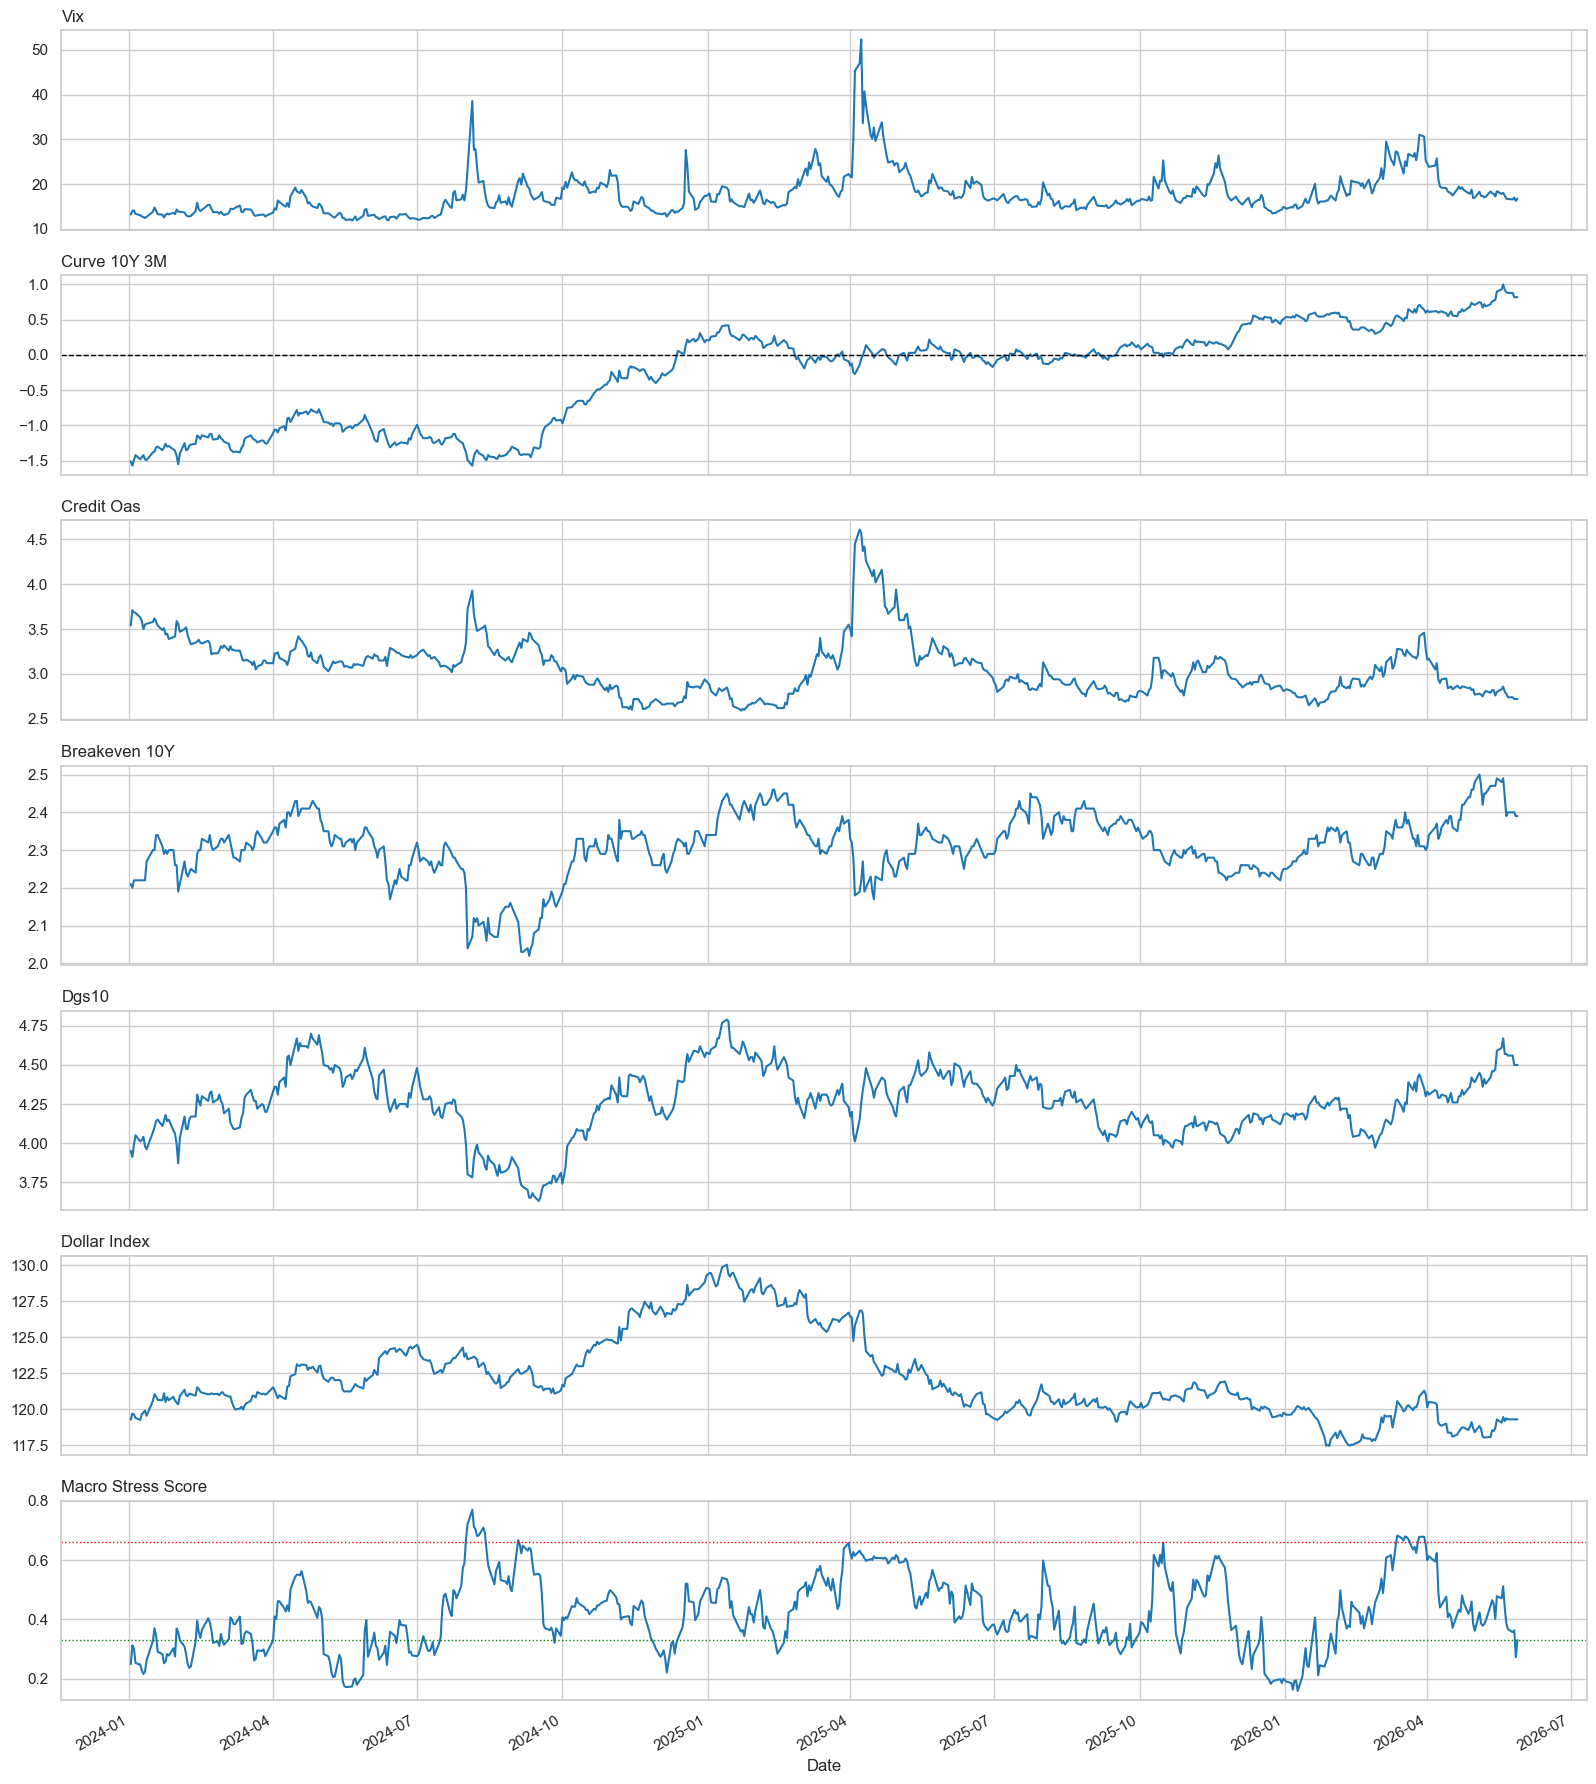

In [6]:
def chart_end_date() -> pd.Timestamp:
    return DATA_END if ALLOW_2026 else VALIDATION_END


def plot_macro_dashboard(features: pd.DataFrame, start=TRAIN_START, end=None):
    if end is None:
        end = chart_end_date()
    chart = features.loc[start:end].copy()
    cols = [
        "vix",
        "curve_10y_3m",
        "credit_oas",
        "breakeven_10y",
        "dgs10",
        "dollar_index",
        "macro_stress_score",
    ]

    fig, axes = plt.subplots(len(cols), 1, figsize=(16, 18), sharex=True)
    for ax, col in zip(axes, cols):
        chart[col].plot(ax=ax, color="#1f77b4", linewidth=1.5)
        ax.set_title(col.replace("_", " ").title(), loc="left")
        if col == "curve_10y_3m":
            ax.axhline(0, color="black", linestyle="--", linewidth=1)
        if col == "macro_stress_score":
            ax.axhline(0.33, color="green", linestyle=":", linewidth=1)
            ax.axhline(0.66, color="red", linestyle=":", linewidth=1)
    plt.tight_layout()
    return fig


plot_macro_dashboard(features_daily)
plt.show()

## Portfolio mechanics

Regime targets are allowed to change quickly, but the actual submitted portfolio must move gradually. The turnover cap below scales the move from the previous submitted allocation toward the new target if the change would exceed 25 percentage points.

In [7]:
REGIMES = ["Risk-On", "Neutral", "Defensive", "Crisis"]


def apply_turnover_cap(
    target: pd.Series,
    previous: pd.Series,
    max_change: float = MAX_TOTAL_ALLOCATION_CHANGE,
) -> pd.Series:
    target = target[ASSETS].astype(float)
    previous = previous[ASSETS].astype(float)
    delta = target - previous
    total_change = float(delta.abs().sum())

    if total_change <= max_change + 1e-12:
        out = target.copy()
    else:
        out = previous + delta * (max_change / total_change)

    out = out.clip(lower=0)
    out = out / out.sum()
    out.name = target.name
    return out


def classify_regime(score: float, thresholds: np.ndarray) -> str:
    t1, t2, t3 = thresholds
    if score <= t1:
        return "Risk-On"
    if score <= t2:
        return "Neutral"
    if score <= t3:
        return "Defensive"
    return "Crisis"


def make_weight_frame(weight_matrix: np.ndarray) -> pd.DataFrame:
    weights = pd.DataFrame(weight_matrix, index=REGIMES, columns=ASSETS)
    weights = weights.div(weights.sum(axis=1), axis=0)
    return weights


def monotonic_penalty(weights: pd.DataFrame) -> float:
    acwi = weights["ACWI"].values
    defensive = weights[["AGG", "GLD", "BSV"]].sum(axis=1).values
    penalty = 0.0
    penalty += np.maximum(np.diff(acwi), 0).sum() * 10
    penalty += np.maximum(-np.diff(defensive), 0).sum() * 10
    return float(penalty)


def simulate_strategy(
    features: pd.DataFrame,
    returns: pd.DataFrame,
    thresholds: np.ndarray,
    regime_weights: pd.DataFrame,
    start: pd.Timestamp,
    end: pd.Timestamp,
    initial_weights: pd.Series | None = None,
):
    decision_features = features.loc[start:end].copy()
    returns_window = returns.loc[start:end].copy()
    decision_dates = decision_features.index.intersection(returns_window.index)

    if initial_weights is None:
        previous = pd.Series({"ACWI": 0.25, "AGG": 0.25, "GLD": 0.25, "BSV": 0.25})
    else:
        previous = initial_weights[ASSETS].astype(float).copy()
        previous = previous / previous.sum()

    actual_weights = []
    target_weights = []
    regimes = []

    for dt in decision_dates:
        score = float(decision_features.loc[dt, "macro_stress_score"])
        regime = classify_regime(score, thresholds)
        target = regime_weights.loc[regime, ASSETS].copy()
        target.name = dt
        actual = apply_turnover_cap(target, previous)
        actual.name = dt

        regimes.append(regime)
        target_weights.append(target)
        actual_weights.append(actual)
        previous = actual

    actual_df = pd.DataFrame(actual_weights)
    target_df = pd.DataFrame(target_weights)
    regime_s = pd.Series(regimes, index=decision_dates, name="regime")

    validate_weights(actual_df, "actual weights")
    validate_turnover(actual_df, "actual weights")

    # Friday weights at t are applied to the next Friday return at t+1.
    aligned_returns = returns_window.reindex(actual_df.index)
    strategy_returns = (actual_df.shift(1) * aligned_returns[ASSETS]).sum(axis=1).dropna()
    strategy_returns.name = "Macro Regime Strategy"

    return {
        "weights": actual_df,
        "targets": target_df,
        "regimes": regime_s,
        "returns": strategy_returns,
    }

## Optimization

The optimizer searches for:

- three stress-score thresholds;
- four legal regime allocations.

It uses 2024 only. The objective rewards risk-adjusted returns and penalizes drawdown, turnover, concentration, and unintuitive regime ordering.

To reduce overfitting, the optimizer uses an internal diversification rule: no regime target may allocate more than 80% to a single asset. The professor allows up to 100%, but this stricter model rule makes the allocation easier to defend.

In [8]:
@dataclass
class MacroParams:
    thresholds: np.ndarray
    regime_weights: pd.DataFrame
    train_objective: float
    train_metrics: pd.Series


def performance_metrics(returns: pd.Series, weights: pd.DataFrame | None = None, rf: float = RISK_FREE_RATE) -> pd.Series:
    returns = returns.dropna()
    if len(returns) == 0:
        return pd.Series(
            {
                "total_return": np.nan,
                "annualized_return": np.nan,
                "annualized_volatility": np.nan,
                "sharpe": np.nan,
                "max_drawdown": np.nan,
                "avg_total_weekly_change": np.nan,
                "avg_conventional_turnover": np.nan,
            }
        )

    cumulative = (1 + returns).cumprod()
    total_return = cumulative.iloc[-1] - 1
    annualized_return = (1 + total_return) ** (52 / len(returns)) - 1
    annualized_vol = returns.std() * np.sqrt(52)
    sharpe = (annualized_return - rf) / annualized_vol if annualized_vol > 0 else np.nan
    drawdown = cumulative / cumulative.cummax() - 1
    max_drawdown = drawdown.min()

    if weights is not None and len(weights) > 1:
        total_weekly_change = weights[ASSETS].diff().abs().sum(axis=1).dropna()
        avg_total_weekly_change = total_weekly_change.mean()
        avg_conventional_turnover = (total_weekly_change / 2).mean()
    else:
        avg_total_weekly_change = np.nan
        avg_conventional_turnover = np.nan

    return pd.Series(
        {
            "total_return": total_return,
            "annualized_return": annualized_return,
            "annualized_volatility": annualized_vol,
            "sharpe": sharpe,
            "max_drawdown": max_drawdown,
            "avg_total_weekly_change": avg_total_weekly_change,
            "avg_conventional_turnover": avg_conventional_turnover,
        }
    )


def objective_from_sim(sim) -> float:
    rets = sim["returns"]
    weights = sim["weights"]
    metrics = performance_metrics(rets, weights)
    if metrics.isna().any():
        return -1e6

    concentration = (weights[ASSETS] ** 2).sum(axis=1).mean()
    drawdown_penalty = abs(metrics["max_drawdown"])
    turnover_penalty = metrics["avg_total_weekly_change"]

    score = (
        metrics["sharpe"]
        - 1.25 * drawdown_penalty
        - 0.40 * turnover_penalty
        - 0.20 * concentration
    )
    return float(score)


def sample_feasible_candidate(rng: np.random.Generator):
    thresholds = np.sort(rng.uniform(0.20, 0.85, size=3))
    if np.min(np.diff(thresholds)) < 0.08:
        thresholds = np.array([0.32, 0.55, 0.74]) + rng.normal(0, 0.025, 3)
        thresholds = np.sort(np.clip(thresholds, 0.20, 0.85))

    acwi = np.sort(rng.uniform(0.05, 0.80, size=4))[::-1]
    # Encourage economically sensible but flexible defensive mixes.
    defensive_mixes = np.array(
        [
            rng.dirichlet([2.0, 1.2, 0.8]),  # Risk-On remaining weights
            rng.dirichlet([1.8, 1.6, 1.2]),  # Neutral
            rng.dirichlet([1.8, 2.0, 1.8]),  # Defensive
            rng.dirichlet([1.2, 2.4, 2.2]),  # Crisis
        ]
    )
    rows = []
    for i in range(4):
        remaining = 1 - acwi[i]
        rows.append(np.r_[acwi[i], defensive_mixes[i] * remaining])

    return thresholds, make_weight_frame(np.vstack(rows))


def pack_params(thresholds: np.ndarray, weights: pd.DataFrame) -> np.ndarray:
    return np.r_[thresholds, weights.loc[REGIMES, ASSETS].values.ravel()]


def unpack_params(x: np.ndarray):
    thresholds = x[:3]
    matrix = x[3:].reshape(4, 4)
    weights = make_weight_frame(matrix)
    return thresholds, weights


def optimize_macro_model(
    features: pd.DataFrame,
    returns: pd.DataFrame,
    n_random_trials: int = 350,
    random_state: int = 42,
) -> MacroParams:
    train_features = features.loc[TRAIN_START:TRAIN_END]
    train_returns = returns.loc[TRAIN_START:TRAIN_END]

    rng = np.random.default_rng(random_state)

    base_thresholds = np.array([0.32, 0.55, 0.74])
    base_weights = pd.DataFrame(
        {
            "ACWI": [0.70, 0.45, 0.25, 0.10],
            "AGG": [0.15, 0.25, 0.35, 0.25],
            "GLD": [0.10, 0.20, 0.25, 0.40],
            "BSV": [0.05, 0.10, 0.15, 0.25],
        },
        index=REGIMES,
    )

    candidates = [(base_thresholds, base_weights)]
    candidates += [sample_feasible_candidate(rng) for _ in range(n_random_trials)]

    best_score = -np.inf
    best_thresholds = None
    best_weights = None
    best_sim = None

    for thresholds, weights in candidates:
        if np.min(np.diff(thresholds)) < 0.05:
            continue
        if weights[ASSETS].max().max() > MAX_MODEL_SINGLE_ASSET_WEIGHT + 1e-12:
            continue
        sim = simulate_strategy(
            train_features,
            train_returns,
            thresholds,
            weights,
            TRAIN_START,
            TRAIN_END,
        )
        score = objective_from_sim(sim) - monotonic_penalty(weights)
        if score > best_score:
            best_score = score
            best_thresholds = thresholds
            best_weights = weights
            best_sim = sim

    def local_objective(x):
        thresholds, weights = unpack_params(x)
        if np.min(np.diff(thresholds)) < 0.05:
            return 1e5
        penalty = monotonic_penalty(weights)
        sim = simulate_strategy(
            train_features,
            train_returns,
            thresholds,
            weights,
            TRAIN_START,
            TRAIN_END,
        )
        return -(objective_from_sim(sim) - penalty)

    constraints = []
    for row in range(4):
        start = 3 + row * 4
        constraints.append({"type": "eq", "fun": lambda x, s=start: np.sum(x[s:s+4]) - 1})

    constraints += [
        {"type": "ineq", "fun": lambda x: x[1] - x[0] - 0.05},
        {"type": "ineq", "fun": lambda x: x[2] - x[1] - 0.05},
        {"type": "ineq", "fun": lambda x: x[3 + 0] - x[3 + 4]},
        {"type": "ineq", "fun": lambda x: x[3 + 4] - x[3 + 8]},
        {"type": "ineq", "fun": lambda x: x[3 + 8] - x[3 + 12]},
    ]

    bounds = (
        [(0.15, 0.90), (0.20, 0.95), (0.25, 0.99)]
        + [(0.0, MAX_MODEL_SINGLE_ASSET_WEIGHT)] * 16
    )

    result = minimize(
        local_objective,
        pack_params(best_thresholds, best_weights),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 250, "disp": False},
    )

    if result.success:
        refined_thresholds, refined_weights = unpack_params(result.x)
        refined_sim = simulate_strategy(
            train_features,
            train_returns,
            refined_thresholds,
            refined_weights,
            TRAIN_START,
            TRAIN_END,
        )
        refined_score = objective_from_sim(refined_sim) - monotonic_penalty(refined_weights)
        if refined_score >= best_score:
            best_thresholds = refined_thresholds
            best_weights = refined_weights
            best_sim = refined_sim
            best_score = refined_score

    validate_weights(best_weights, "optimized regime weights")
    train_metrics = performance_metrics(best_sim["returns"], best_sim["weights"])

    return MacroParams(
        thresholds=np.asarray(best_thresholds),
        regime_weights=best_weights,
        train_objective=float(best_score),
        train_metrics=train_metrics,
    )


# Frozen parameters from the pre-2026 research run.
# When ALLOW_2026=True, the notebook uses these constants and does not re-optimize.
# This prevents accidental live-period retuning or human-in-the-loop leakage.
FROZEN_THRESHOLDS = np.array([0.252, 0.371, 0.462])
FROZEN_REGIME_WEIGHTS = pd.DataFrame(
    {
        "ACWI": [0.5020, 0.1980, 0.1978, 0.1978],
        "AGG":  [0.2500, 0.0000, 0.0023, 0.2503],
        "GLD":  [0.0000, 0.7553, 0.0000, 0.3804],
        "BSV":  [0.2480, 0.0468, 0.7999, 0.1714],
    },
    index=REGIMES,
)
FROZEN_REGIME_WEIGHTS = FROZEN_REGIME_WEIGHTS.div(FROZEN_REGIME_WEIGHTS.sum(axis=1), axis=0)


if ALLOW_2026:
    frozen_sim = simulate_strategy(
        weekly_features,
        weekly_returns,
        FROZEN_THRESHOLDS,
        FROZEN_REGIME_WEIGHTS,
        TRAIN_START,
        TRAIN_END,
    )
    params = MacroParams(
        thresholds=FROZEN_THRESHOLDS,
        regime_weights=FROZEN_REGIME_WEIGHTS,
        train_objective=objective_from_sim(frozen_sim) - monotonic_penalty(FROZEN_REGIME_WEIGHTS),
        train_metrics=performance_metrics(frozen_sim["returns"], frozen_sim["weights"]),
    )
    print("Using frozen pre-2026 parameters. Optimization skipped because ALLOW_2026=True.")
else:
    params = optimize_macro_model(weekly_features, weekly_returns)
    print("Optimization run in research mode using 2024 only.")

print("Strategy thresholds:", np.round(params.thresholds, 3))
display((params.regime_weights * 100).round(2))
display(params.train_metrics.to_frame("2024 Train"))

Using frozen pre-2026 parameters. Optimization skipped because ALLOW_2026=True.
Strategy thresholds: [0.252 0.371 0.462]


,ACWI,AGG,GLD,BSV
Risk-On,50.20,25.00,0.00,24.80
Neutral,19.80,0.00,75.52,4.68
Defensive,19.78,0.23,0.00,79.99
Crisis,19.78,25.03,38.04,17.14


,2024 Train
total_return,0.262507
annualized_return,0.262507
annualized_volatility,0.074975
sharpe,2.967744
max_drawdown,-0.016369
avg_total_weekly_change,0.190104
avg_conventional_turnover,0.095052


## Frozen-parameter validation

The next cells run the frozen 2024-trained model through 2025. No 2025 optimization occurs here.

In [9]:
BACKTEST_END = DATA_END if ALLOW_2026 else VALIDATION_END

full_sim = simulate_strategy(
    weekly_features,
    weekly_returns,
    params.thresholds,
    params.regime_weights,
    TRAIN_START,
    BACKTEST_END,
)

weights_full = full_sim["weights"]
regimes_full = full_sim["regimes"]
returns_full = full_sim["returns"]

train_returns = returns_full.loc[TRAIN_START:TRAIN_END]
validation_returns = returns_full.loc[VALIDATION_START:VALIDATION_END]
train_weights = weights_full.loc[TRAIN_START:TRAIN_END]
validation_weights = weights_full.loc[VALIDATION_START:VALIDATION_END]

metric_blocks = [
    performance_metrics(train_returns, train_weights).rename("2024 Train"),
    performance_metrics(validation_returns, validation_weights).rename("2025 Validation"),
]
rule_blocks = [
    assignment_rule_report(train_weights, "2024 Train"),
    assignment_rule_report(validation_weights, "2025 Validation"),
]

if ALLOW_2026:
    live_returns = returns_full.loc[LIVE_MONITOR_START:BACKTEST_END]
    live_weights = weights_full.loc[LIVE_MONITOR_START:BACKTEST_END]
    if len(live_weights) > 0:
        metric_blocks.append(performance_metrics(live_returns, live_weights).rename("2026 Live Monitor"))
        rule_blocks.append(assignment_rule_report(live_weights, "2026 Live Monitor"))
        print(f"2026 live monitor included through {live_weights.index.max().date()}.")
    else:
        print("ALLOW_2026=True, but no 2026 weekly rows are available yet.")

metrics = pd.concat(metric_blocks, axis=1)
rule_report = pd.concat(rule_blocks, axis=1)

display(metrics.round(4))
display(rule_report)

2026 live monitor included through 2026-05-22.


,2024 Train,2025 Validation,2026 Live Monitor
total_return,0.2625,0.3485,0.0024
annualized_return,0.2625,0.3485,0.0061
annualized_volatility,0.0750,0.0788,0.0969
sharpe,2.9677,3.9122,-0.3500
max_drawdown,-0.0164,-0.0225,-0.0654
avg_total_weekly_change,0.1901,0.1655,0.1957
avg_conventional_turnover,0.0951,0.0828,0.0979


,2024 Train,2025 Validation,2026 Live Monitor
rows,52,52,21
sum_to_100_pct,True,True,True
long_only,True,True,True
max_asset_weight,0.7999,0.7999,0.567668
max_total_weekly_change,0.25,0.25,0.25


## Benchmarks

The presentation should compare the macro strategy with simple rules from class:

- 60/40: 60% `ACWI`, 40% `AGG`.
- Permanent portfolio: 25% each in `ACWI`, `AGG`, `GLD`, `BSV`.

In [10]:
def constant_strategy_returns(returns: pd.DataFrame, weights: dict, name: str) -> pd.Series:
    w = pd.Series(weights).reindex(ASSETS).fillna(0.0)
    w = w / w.sum()
    out = (returns[ASSETS] * w).sum(axis=1)
    out.name = name
    return out


benchmark_returns = pd.concat(
    [
        returns_full.rename("Macro Regime Strategy"),
        constant_strategy_returns(weekly_returns, {"ACWI": 0.60, "AGG": 0.40}, "60/40 Portfolio"),
        constant_strategy_returns(
            weekly_returns,
            {"ACWI": 0.25, "AGG": 0.25, "GLD": 0.25, "BSV": 0.25},
            "Permanent Portfolio",
        ),
    ],
    axis=1,
).loc[TRAIN_START:BACKTEST_END].dropna()

benchmark_metrics_full = pd.concat(
    [
        performance_metrics(benchmark_returns[col]).rename(col)
        for col in benchmark_returns.columns
    ],
    axis=1,
)

print("Full backtest period (2024 → latest):")
display(benchmark_metrics_full.round(4))


# Per-period breakdown so 60/40 and the Permanent Portfolio can be compared with
# the strategy's 2024 Train / 2025 Validation / 2026 Live Monitor table above.
periods = [
    ("2024 Train", TRAIN_START, TRAIN_END),
    ("2025 Validation", VALIDATION_START, VALIDATION_END),
]
if ALLOW_2026:
    periods.append(("2026 Live Monitor", LIVE_MONITOR_START, BACKTEST_END))


def benchmark_metrics_by_period(period_returns: pd.DataFrame) -> pd.DataFrame:
    return pd.concat(
        [
            performance_metrics(period_returns[col]).rename(col)
            for col in period_returns.columns
        ],
        axis=1,
    )


per_period_tables = {}
for label, start, end in periods:
    window = benchmark_returns.loc[start:end].dropna(how="all")
    if window.empty:
        continue
    per_period_tables[label] = benchmark_metrics_by_period(window)
    print(f"\n{label} ({window.index.min().date()} → {window.index.max().date()}):")
    display(per_period_tables[label].round(4))


# Sharpe-only summary for the presentation slide.
sharpe_summary = pd.DataFrame(
    {label: table.loc["sharpe"] for label, table in per_period_tables.items()}
)
print("\nSharpe ratios by period (risk-free rate = {:.0%}):".format(RISK_FREE_RATE))
display(sharpe_summary.round(4))

,Macro Regime Strategy,60/40 Portfolio,Permanent Portfolio
total_return,0.7066,0.3699,0.4393
annualized_return,0.2490,0.1399,0.1636
annualized_volatility,0.0811,0.0880,0.0678
sharpe,2.5760,1.1356,1.8228
max_drawdown,-0.0654,-0.0779,-0.0670
avg_total_weekly_change,NaN,NaN,NaN
avg_conventional_turnover,NaN,NaN,NaN


## Visual 2: regime timeline

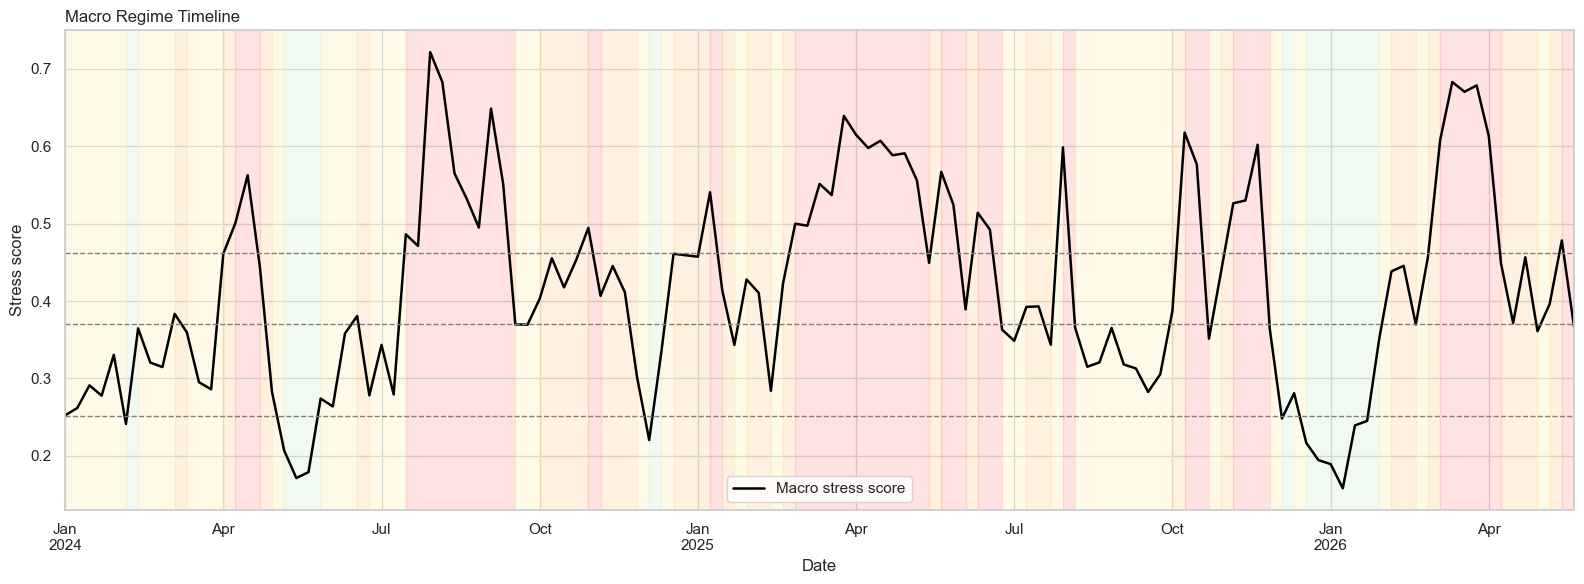

In [11]:
def plot_regime_timeline(features: pd.DataFrame, regimes: pd.Series, thresholds: np.ndarray):
    end = chart_end_date()
    chart = features.loc[TRAIN_START:end].copy()
    regime_chart = regimes.loc[TRAIN_START:end].reindex(chart.index, method="ffill")

    colors = {
        "Risk-On": "#d8f3dc",
        "Neutral": "#fff3bf",
        "Defensive": "#ffd6a5",
        "Crisis": "#ffadad",
    }

    fig, ax = plt.subplots(figsize=(16, 6))
    chart["macro_stress_score"].plot(ax=ax, color="black", linewidth=1.8, label="Macro stress score")
    for threshold in thresholds:
        ax.axhline(threshold, color="gray", linestyle="--", linewidth=1)

    # Shade weekly regimes.
    current_start = None
    current_regime = None
    for dt, regime in regime_chart.items():
        if pd.isna(regime):
            continue
        if current_regime is None:
            current_start = dt
            current_regime = regime
        elif regime != current_regime:
            ax.axvspan(current_start, dt, color=colors[current_regime], alpha=0.35)
            current_start = dt
            current_regime = regime
    if current_regime is not None:
        ax.axvspan(current_start, chart.index.max(), color=colors[current_regime], alpha=0.35)

    ax.set_title("Macro Regime Timeline", loc="left")
    ax.set_ylabel("Stress score")
    ax.legend()
    plt.tight_layout()
    return fig


plot_regime_timeline(weekly_features, regimes_full, params.thresholds)
plt.show()

## Visual 3: allocation chart

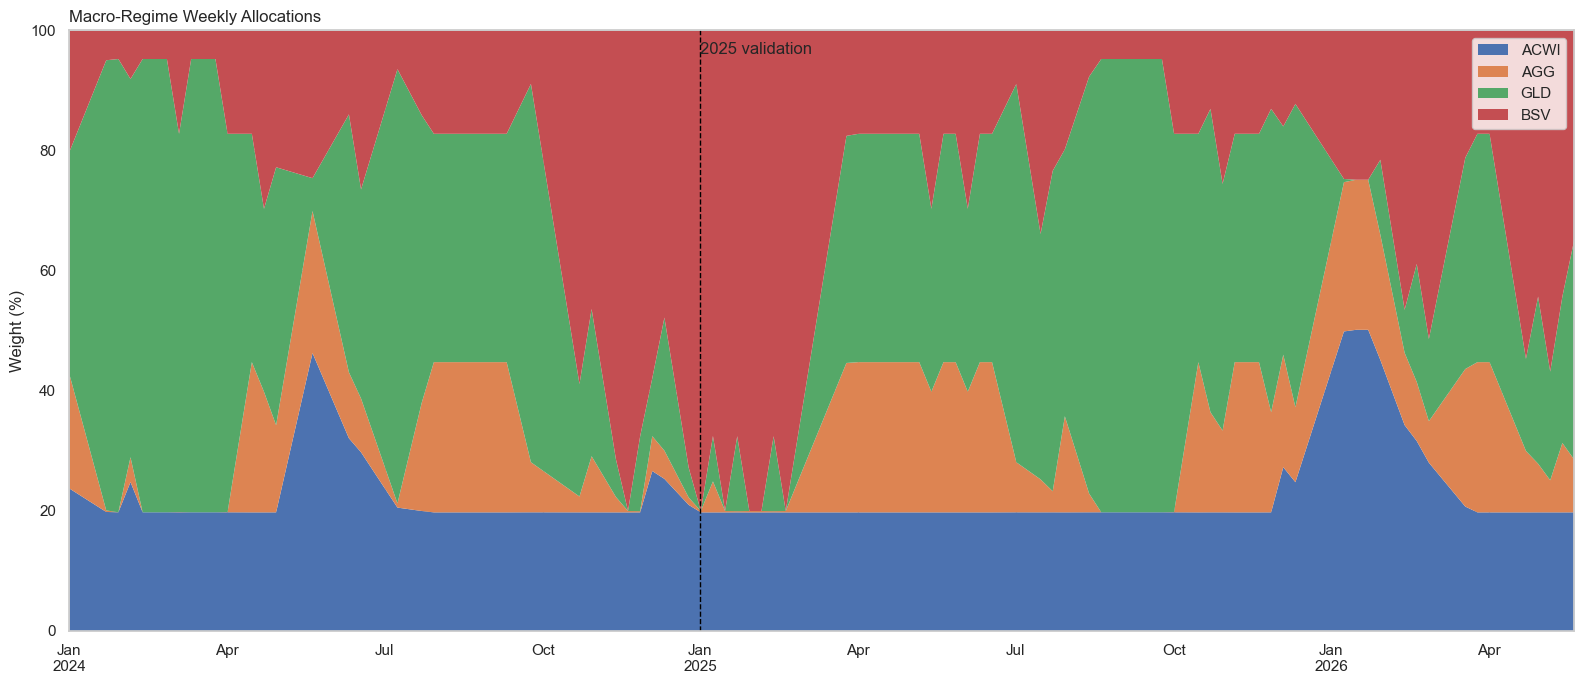

In [12]:
def plot_allocations(weights: pd.DataFrame):
    chart = weights.loc[TRAIN_START:chart_end_date(), ASSETS] * 100
    ax = chart.plot.area(figsize=(16, 7), linewidth=0)
    ax.set_title("Macro-Regime Weekly Allocations", loc="left")
    ax.set_ylabel("Weight (%)")
    ax.set_ylim(0, 100)
    ax.axvline(VALIDATION_START, color="black", linestyle="--", linewidth=1)
    ax.text(VALIDATION_START, 98, "2025 validation", va="top")
    plt.tight_layout()
    return ax


plot_allocations(weights_full)
plt.show()

## Visual 4: backtest comparison

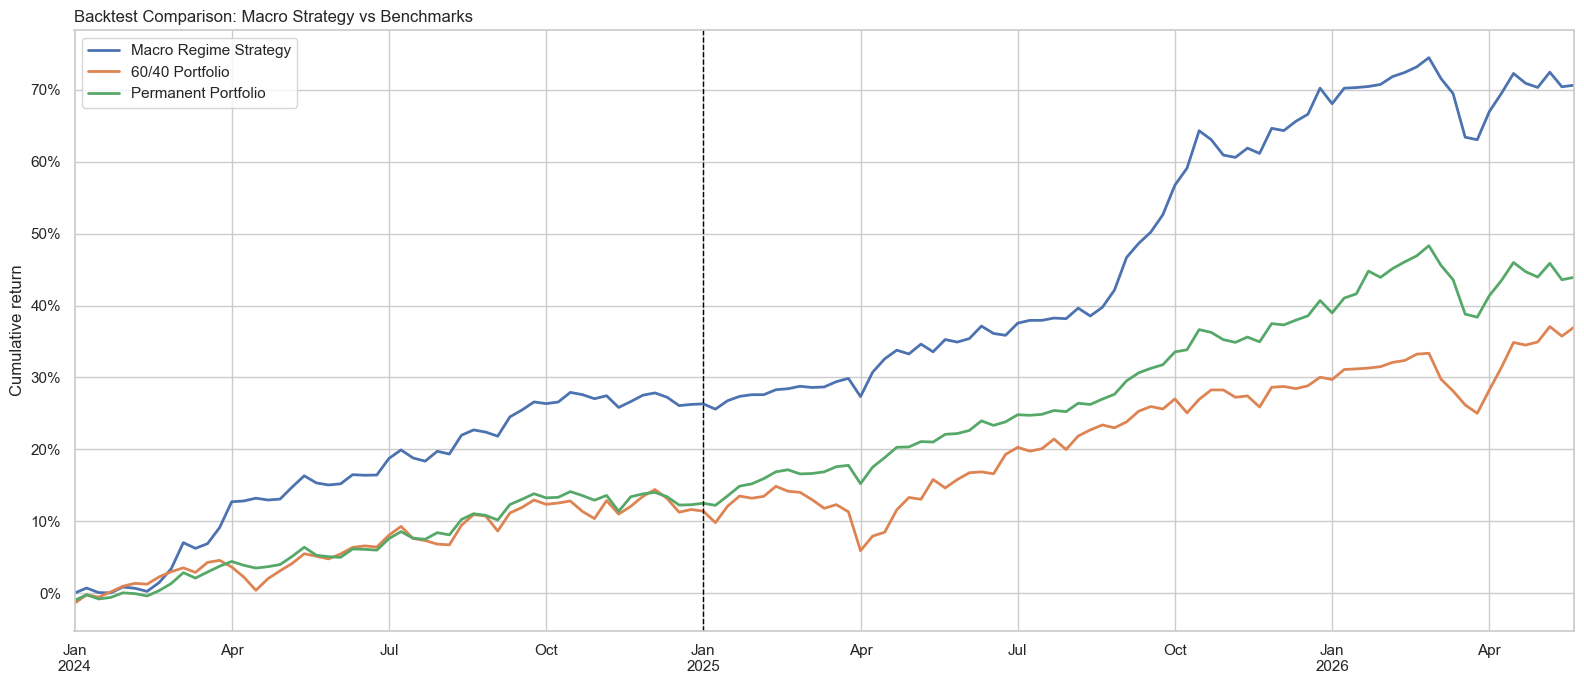

In [13]:
def plot_backtest_comparison(strategy_returns: pd.DataFrame):
    cumulative = (1 + strategy_returns).cumprod() - 1
    ax = cumulative.plot(figsize=(16, 7), linewidth=2)
    ax.axvline(VALIDATION_START, color="black", linestyle="--", linewidth=1)
    ax.set_title("Backtest Comparison: Macro Strategy vs Benchmarks", loc="left")
    ax.set_ylabel("Cumulative return")
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    plt.tight_layout()
    return ax


plot_backtest_comparison(benchmark_returns)
plt.show()

## Professor-format CSV generator

Use this after the team unlocks 2026 live data. The function writes exactly one row with the required columns:

`week,team_id,acwi,agg,gld,bsv`

Weights are written as numeric percentages without the `%` sign.

In [14]:
def next_submission_date(as_of: str | pd.Timestamp | None = None) -> pd.Timestamp:
    if as_of is None:
        as_of = pd.Timestamp.today().normalize()
    as_of = pd.Timestamp(as_of).normalize()
    upcoming = SUBMISSION_DATES[SUBMISSION_DATES >= as_of]
    if len(upcoming) > 0:
        return pd.Timestamp(upcoming[0])
    return pd.Timestamp(SUBMISSION_DATES[-1])


def professor_csv_row(weights: pd.Series, week: str | pd.Timestamp, team_id: str = TEAM_ID) -> pd.DataFrame:
    week = pd.Timestamp(week)
    if not ALLOW_2026 and week >= BLIND_OOS_START:
        raise RuntimeError("Cannot generate a 2026 submission while ALLOW_2026=False.")

    weights = weights[ASSETS].astype(float)
    weights = weights / weights.sum()
    validate_weights(weights, "CSV weights")

    row = pd.DataFrame(
        [
            {
                "week": week.strftime("%Y-%m-%d"),
                "team_id": team_id,
                "acwi": round(weights["ACWI"] * 100, 4),
                "agg": round(weights["AGG"] * 100, 4),
                "gld": round(weights["GLD"] * 100, 4),
                "bsv": round(weights["BSV"] * 100, 4),
            }
        ],
        columns=["week", "team_id", "acwi", "agg", "gld", "bsv"],
    )

    if len(row) != 1:
        raise ValueError("Professor CSV must contain exactly one row.")
    return row


def write_professor_csv(weights: pd.Series, week: str | pd.Timestamp, team_id: str = TEAM_ID) -> Path:
    row = professor_csv_row(weights, week, team_id)
    week_str = pd.Timestamp(week).strftime("%Y-%m-%d")
    output_path = OUTPUT_DIR / f"{team_id}_{week_str}.csv"
    row.to_csv(output_path, index=False)
    return output_path


print("Official submission dates:", [d.strftime("%Y-%m-%d") for d in SUBMISSION_DATES])
print("Next official submission date from today:", next_submission_date().strftime("%Y-%m-%d"))

# Validation-format example only. This is intentionally not the live 2026 submission.
latest_validation_date = validation_weights.index.max()
example_row = professor_csv_row(validation_weights.loc[latest_validation_date], latest_validation_date)
print("Validation-format example, not the live 2026 submission:")
display(example_row)

Official submission dates: ['2026-05-29', '2026-06-05', '2026-06-12', '2026-06-19', '2026-06-26']
Next official submission date from today: 2026-05-29
Validation-format example, not the live 2026 submission:


,week,team_id,acwi,agg,gld,bsv
0,2025-12-26,TeamXX,37.367,18.6798,25.5385,18.4148


## Live weekly runner template

After the blind period is intentionally unlocked, this is the workflow for each Friday:

1. Set `ALLOW_2026 = True`.
2. Rerun data loading and feature engineering.
3. Keep the optimized 2024 parameters frozen.
4. Generate the latest target allocation.
5. Apply the 25 percentage point change cap versus the previously submitted allocation.
6. Export the professor-format CSV.

Do **not** re-optimize thresholds or allocations on 2026 live results.

In [15]:
def latest_live_allocation(
    features: pd.DataFrame,
    thresholds: np.ndarray,
    regime_weights: pd.DataFrame,
    previous_submitted_weights: pd.Series | None = None,
    run_date: str | pd.Timestamp | None = None,
) -> pd.Series:
    if run_date is None:
        run_date = pd.Timestamp.today().normalize()
    run_date = pd.Timestamp(run_date)

    available = features.loc[:run_date]
    if available.empty:
        raise ValueError("No macro features available before run_date.")

    latest_signal_date = available.index.max()
    latest_score = float(available.loc[latest_signal_date, "macro_stress_score"])
    latest_regime = classify_regime(latest_score, thresholds)
    target = regime_weights.loc[latest_regime, ASSETS].copy()

    # The first official submission has no previous submitted portfolio.
    # For later Fridays, pass the prior CSV weights as previous_submitted_weights.
    if previous_submitted_weights is None:
        actual = target / target.sum()
    else:
        actual = apply_turnover_cap(target, previous_submitted_weights)

    actual.name = latest_signal_date

    print(f"Latest signal date used: {latest_signal_date.date()}")
    print(f"Macro score: {latest_score:.3f}")
    print(f"Regime: {latest_regime}")
    if previous_submitted_weights is None:
        print("First submission mode: no previous submitted weights, so no turnover cap is applied.")
    else:
        print(f"Total allocation change: {(actual - previous_submitted_weights[ASSETS]).abs().sum():.3f}")
    return actual


def generate_live_submission(
    features: pd.DataFrame,
    thresholds: np.ndarray,
    regime_weights: pd.DataFrame,
    submission_date: str | pd.Timestamp | None = None,
    previous_submitted_weights: pd.Series | None = None,
    run_date: str | pd.Timestamp | None = None,
    team_id: str = TEAM_ID,
    write_csv: bool = False,
):
    if not ALLOW_2026:
        raise RuntimeError("Set ALLOW_2026=True to generate the live 2026 submission.")

    if submission_date is None:
        submission_date = next_submission_date()
    submission_date = pd.Timestamp(submission_date)

    if run_date is None:
        run_date = min(pd.Timestamp.today().normalize(), submission_date)

    live_weights = latest_live_allocation(
        features=features,
        thresholds=thresholds,
        regime_weights=regime_weights,
        previous_submitted_weights=previous_submitted_weights,
        run_date=run_date,
    )
    row = professor_csv_row(live_weights, submission_date, team_id=team_id)

    print(f"CSV week/submission date: {submission_date.date()}")
    if write_csv:
        output_path = write_professor_csv(live_weights, submission_date, team_id=team_id)
        print(f"Wrote CSV: {output_path}")

    return live_weights, row


if ALLOW_2026:
    # Preview for the next official Friday. On the actual Friday, rerun the notebook
    # so the latest Friday data is included. For submissions after May 29, pass the
    # prior submitted CSV weights as previous_submitted_weights.
    live_weights, live_submission_row = generate_live_submission(
        weekly_features,
        params.thresholds,
        params.regime_weights,
        submission_date=next_submission_date(),
        previous_submitted_weights=None,
        write_csv=False,
    )
    display((live_weights * 100).round(2).to_frame("live_weight_pct"))
    display(live_submission_row)
else:
    print("2026 live runner is locked. Set ALLOW_2026=True when the team is ready.")

Latest signal date used: 2026-05-22
Macro score: 0.367
Regime: Neutral
First submission mode: no previous submitted weights, so no turnover cap is applied.
CSV week/submission date: 2026-05-29


,live_weight_pct
ACWI,19.80
AGG,0.00
GLD,75.52
BSV,4.68


,week,team_id,acwi,agg,gld,bsv
0,2026-05-29,TeamXX,19.798,0.0,75.5224,4.6795


## Final checklist

Run these assertions before using any allocation:

In [16]:
assert_no_2026_data(weekly_features, "weekly_features")
assert_no_2026_data(weekly_returns, "weekly_returns")
validate_weights(weights_full, "full strategy weights")
validate_turnover(weights_full, "full strategy weights")

assert set(ASSETS) == {"ACWI", "AGG", "GLD", "BSV"}
assert list(example_row.columns) == ["week", "team_id", "acwi", "agg", "gld", "bsv"]
assert len(example_row) == 1

if ALLOW_2026:
    assert list(live_submission_row.columns) == ["week", "team_id", "acwi", "agg", "gld", "bsv"]
    assert len(live_submission_row) == 1
    validate_weights(live_weights, "live submission weights")

print("All assignment checks passed.")

All assignment checks passed.
